In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models

In [2]:
SEQUENCE_LENGTH = 16
BATCH_SIZE = 4
EPOCHS = 15
LR = 0.0005
NUM_WORKERS = 2
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_SAVE_PATH = "resnet50_lstm_best.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla P100-PCIE-16GB


In [3]:
DATA_ROOT = "/kaggle/input/datasets/webadvisor/real-time-anomaly-detection-in-cctv-surveillance"

for d in os.listdir(DATA_ROOT):
    candidate = os.path.join(DATA_ROOT, d)
    if os.path.isdir(candidate):
        if "data" in os.listdir(candidate):
            DATA_ROOT = candidate
            break

print("Using dataset root:", DATA_ROOT)

TRAIN_CSV = os.path.join(DATA_ROOT, "data/train.csv")
TEST_CSV = os.path.join(DATA_ROOT, "data/test.csv")

Using dataset root: /kaggle/input/datasets/webadvisor/real-time-anomaly-detection-in-cctv-surveillance


In [4]:
def fix_path(p):
    return p.replace("\\", "/")

def prepare_csv(csv_path):
    df = pd.read_csv(csv_path)

    df["video_name"] = df["video_name"].apply(fix_path)
    df["video_name"] = DATA_ROOT + "/" + df["video_name"].astype(str)

    return df

train_df = prepare_csv(TRAIN_CSV)
test_df = prepare_csv(TEST_CSV)

print("Train samples:", len(train_df))
print("Test samples:", len(test_df))

train_df.head()

Train samples: 1520
Test samples: 380


,Unnamed: 0,label,video_name
0,1229,normal,/kaggle/input/datasets/webadvisor/real-time-an...
1,551,normal,/kaggle/input/datasets/webadvisor/real-time-an...
2,715,normal,/kaggle/input/datasets/webadvisor/real-time-an...
3,1366,roadaccidents,/kaggle/input/datasets/webadvisor/real-time-an...
4,501,normal,/kaggle/input/datasets/webadvisor/real-time-an...


In [5]:
classes = sorted(train_df["label"].unique())
class_to_idx = {cls: i for i, cls in enumerate(classes)}
num_classes = len(classes)

print("Classes:", class_to_idx)

Classes: {'abuse': 0, 'arrest': 1, 'arson': 2, 'assault': 3, 'burglary': 4, 'explosion': 5, 'fighting': 6, 'normal': 7, 'roadaccidents': 8, 'robbery': 9, 'shooting': 10, 'shoplifting': 11, 'stealing': 12, 'vandalism': 13}


In [ ]:
class CSVVideoDataset(Dataset):
    def __init__(self, dataframe, sequence_length=16, transform=None, class_to_idx=None):
        self.data = dataframe
        self.sequence_length = sequence_length
        self.transform = transform
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.data)

    def _sample_frames(self, video_path):
        cap = cv2.VideoCapture(video_path)
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        if frame_count <= 0:
            raise RuntimeError(f"Invalid video: {video_path}")

        indices = np.linspace(0, frame_count - 1, self.sequence_length).astype(int)

        frames = []
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()

            if not ret:
                if len(frames) > 0:
                    frame = frames[-1]
                else:
                    frame = np.zeros((224, 224, 3), dtype=np.uint8)

            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)

        cap.release()
        return frames

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
   
        video_path = row["video_name"]
        label_name = row["label"]
        label = self.class_to_idx[label_name]

        frames = self._sample_frames(video_path)

        if self.transform:
            frames = [self.transform(frame) for frame in frames]

        frames = torch.stack(frames)
        return frames, label

In [7]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = CSVVideoDataset(train_df, SEQUENCE_LENGTH, transform, class_to_idx)
val_dataset = CSVVideoDataset(test_df, SEQUENCE_LENGTH, transform, class_to_idx)

print("Dataset ready.")

Dataset ready.


In [8]:
def compute_class_weights(df, class_to_idx):
    counts = Counter(df["label"])
    total = sum(counts.values())
    num_classes = len(class_to_idx)

    weights = []
    for cls, idx in sorted(class_to_idx.items(), key=lambda x: x[1]):
        count = counts.get(cls, 1)
        weights.append(total / (num_classes * count))

    return torch.tensor(weights, dtype=torch.float)

class_weights = compute_class_weights(train_df, class_to_idx).to(DEVICE)
print("Class weights:", class_weights)

Class weights: tensor([2.7143, 2.7143, 2.7143, 2.7143, 1.3571, 2.7143, 2.7143, 0.1429, 0.9048,
        0.9048, 2.7143, 2.7143, 1.3571, 2.7143], device='cuda:0')


In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("Dataloaders ready.")

Dataloaders ready.


In [10]:
class ResNet50LSTM(nn.Module):
    def __init__(self, num_classes, hidden_size=256):
        super().__init__()

        backbone = models.resnet50(weights="IMAGENET1K_V1")
        # ResNet50 feature extractor: everything except the final FC
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])

        # Freeze early layers (conv1, bn1, relu, maxpool, layer1, layer2)
        freeze_until = 6
        for i, child in enumerate(self.feature_extractor):
            if i < freeze_until:
                for param in child.parameters():
                    param.requires_grad = False

        # ResNet50 outputs 2048-dim features
        feature_dim = 2048

        self.lstm = nn.LSTM(
            input_size=feature_dim,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        B, T, C, H, W = x.size()
        x = x.view(B * T, C, H, W)

        features = self.feature_extractor(x)
        features = features.view(B, T, -1)

        _, (h_n, _) = self.lstm(features)
        final_hidden = h_n[-1]

        return self.fc(final_hidden)

model = ResNet50LSTM(num_classes).to(DEVICE)
print("Model ready.")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 183MB/s] 


Model ready.


In [11]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR
)

print("Training setup ready.")

Training setup ready.


In [12]:
def train_model(model, train_loader, val_loader, criterion, optimizer):
    best_val_acc = 0.0

    for epoch in range(EPOCHS):
        # TRAIN
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        for videos, labels in train_loader:
            videos, labels = videos.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(videos)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total

        # VALIDATION
        model.eval()
        correct = 0
        total = 0
        val_loss = 0

        with torch.no_grad():
            for videos, labels in val_loader:
                videos, labels = videos.to(DEVICE), labels.to(DEVICE)
                outputs = model(videos)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                preds = outputs.argmax(1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_acc = correct / total

        print(f"Epoch {epoch+1}/{EPOCHS}")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
        print("-" * 40)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), MODEL_SAVE_PATH)
            print("Best model saved.")

In [13]:
train_model(model, train_loader, val_loader, criterion, optimizer)

Epoch 1/15
Train Loss: 978.6853 | Train Acc: 0.4178
Val Loss:   239.1693 | Val Acc:   0.4184
----------------------------------------
Best model saved.
Epoch 2/15
Train Loss: 953.9930 | Train Acc: 0.4184
Val Loss:   244.2973 | Val Acc:   0.4526
----------------------------------------
Best model saved.
Epoch 3/15
Train Loss: 954.4359 | Train Acc: 0.4257
Val Loss:   231.7264 | Val Acc:   0.4132
----------------------------------------
Epoch 4/15
Train Loss: 941.1196 | Train Acc: 0.4243
Val Loss:   233.0871 | Val Acc:   0.5184
----------------------------------------
Best model saved.
Epoch 5/15
Train Loss: 938.4867 | Train Acc: 0.4592
Val Loss:   229.9093 | Val Acc:   0.4658
----------------------------------------
Epoch 6/15
Train Loss: 933.5674 | Train Acc: 0.4605
Val Loss:   232.0462 | Val Acc:   0.4053
----------------------------------------
Epoch 7/15
Train Loss: 923.6670 | Train Acc: 0.4493
Val Loss:   228.4821 | Val Acc:   0.4053
----------------------------------------
Epoch 8/

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for videos, labels in val_loader:
        videos = videos.to(DEVICE)
        outputs = model(videos)
        preds = outputs.argmax(1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))

Confusion Matrix:
[[  1   0   0   0   2   0   0   4   2   0   0   0   0   1]
 [  3   0   1   0   1   0   0   1   2   1   0   0   0   1]
 [  4   0   2   0   0   0   0   0   1   1   0   0   1   1]
 [  0   0   3   0   2   0   0   2   1   1   0   0   0   1]
 [  0   0   2   0   5   0   0   2   6   2   0   1   2   0]
 [  4   0   1   0   1   0   0   1   2   0   0   0   0   1]
 [  3   0   1   0   3   0   0   0   1   1   0   0   0   1]
 [  2   0   0   0   5   0   0 116  25  11   0  17   5   9]
 [  6   0   1   0   4   0   0   5  12   0   1   1   0   0]
 [  1   0   1   0   5   0   0   5   6   5   0   1   3   3]
 [  1   0   1   0   3   0   0   1   0   1   0   0   0   3]
 [  0   0   0   0   3   0   0   3   1   0   0   2   1   0]
 [  1   0   2   0   7   0   0   1   5   1   0   0   2   1]
 [  0   0   2   0   4   0   0   1   0   1   0   0   0   2]]

Classification Report:
               precision    recall  f1-score   support

        abuse       0.04      0.10      0.06        10
       arrest       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [17]:
model.load_state_dict(torch.load("resnet50_lstm_best.pth", map_location=DEVICE))
model.eval()

def predict_video(video_path):
    frames = train_dataset._sample_frames(video_path)
    frames = [transform(f) for f in frames]
    frames = torch.stack(frames).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = model(frames)
        pred = output.argmax(1).item()

    return classes[pred]

# Example

In [23]:
video_path = "/kaggle/input/datasets/webadvisor/real-time-anomaly-detection-in-cctv-surveillance/data/normal/Normal_Videos004_x264.mp4"
print("Prediction:", predict_video(video_path))

Prediction: normal


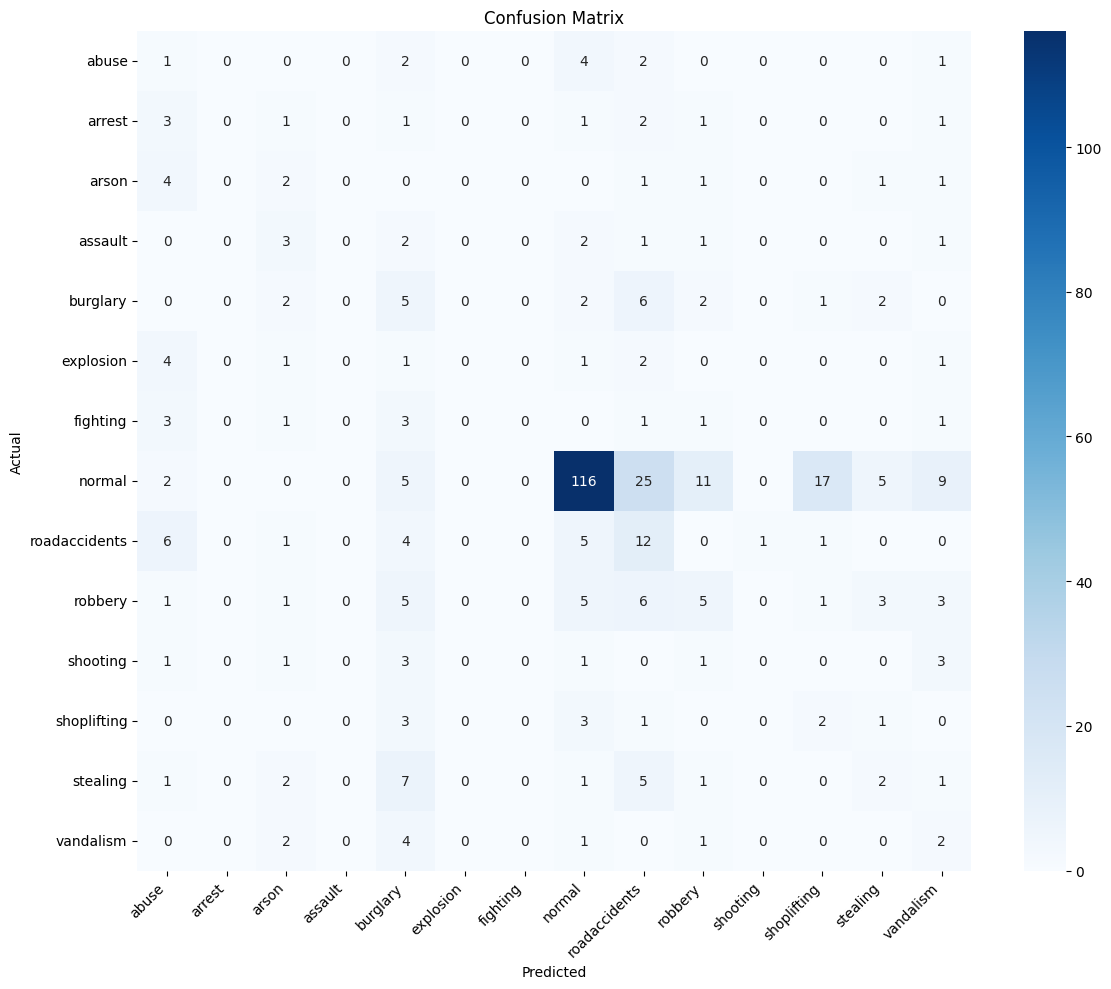

In [28]:
from matplotlib import pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models

In [36]:
SEQUENCE_LENGTH = 16
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_PATH = "resnet50_lstm_best.pth"
DATA_DIR = "/kaggle/input/datasets/webadvisor/real-time-anomaly-detection-in-cctv-surveillance/data"

classes = ['abuse', 'arrest', 'arson', 'assault', 'burglary', 'explosion',
           'fighting', 'normal', 'roadaccidents', 'robbery', 'shooting',
           'shoplifting', 'stealing', 'vandalism']

print("Using device:", DEVICE)

Using device: cuda


In [37]:
class ResNet50LSTM(nn.Module):
    def __init__(self, num_classes, hidden_size=256):
        super().__init__()

        backbone = models.resnet50(weights=None)
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])

        feature_dim = 2048

        self.lstm = nn.LSTM(
            input_size=feature_dim,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        B, T, C, H, W = x.size()
        x = x.view(B * T, C, H, W)

        features = self.feature_extractor(x)
        features = features.view(B, T, -1)

        _, (h_n, _) = self.lstm(features)
        final_hidden = h_n[-1]

        return self.fc(final_hidden)

model = ResNet50LSTM(num_classes=len(classes)).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print("Model loaded successfully!")

Model loaded successfully!


In [38]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def sample_frames(video_path, sequence_length=16):
    cap = cv2.VideoCapture(video_path)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if frame_count <= 0:
        raise RuntimeError(f"Invalid video: {video_path}")

    indices = np.linspace(0, frame_count - 1, sequence_length).astype(int)

    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()

        if not ret:
            if len(frames) > 0:
                frame = frames[-1]
            else:
                frame = np.zeros((224, 224, 3), dtype=np.uint8)

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)

    cap.release()
    return frames

def predict_video(video_path):
    frames = sample_frames(video_path, SEQUENCE_LENGTH)
    frames = [transform(f) for f in frames]
    frames = torch.stack(frames).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = model(frames)
        probabilities = torch.softmax(output, dim=1)[0]
        pred_idx = output.argmax(1).item()
        confidence = probabilities[pred_idx].item() * 100

    return classes[pred_idx], confidence

In [39]:
# Classify all videos inside each class folder under data/
results = []

class_folders = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
])

for folder in class_folders:
    folder_path = os.path.join(DATA_DIR, folder)
    actual_label = folder

    video_files = sorted([
        f for f in os.listdir(folder_path)
        if f.lower().endswith(('.mp4', '.avi', '.mov', '.mkv'))
    ])

    print(f"\n{'='*100}")
    print(f"  Folder: {folder} ({len(video_files)} videos)")
    print(f"{'='*100}")
    print(f"{'Video File':40s} {'Actual':18s} {'Predicted':18s} {'Confidence':>10s}  Result")
    print(f"{'-'*100}")

    for video_file in video_files:
        video_path = os.path.join(folder_path, video_file)

        try:
            prediction, confidence = predict_video(video_path)
            is_correct = prediction == actual_label
            status = "CORRECT" if is_correct else "WRONG"

            print(f"{video_file:40s} {actual_label:18s} {prediction:18s} {confidence:9.1f}%  {status}")

            results.append({
                "video": video_file,
                "folder": actual_label,
                "prediction": prediction,
                "confidence": confidence,
                "correct": is_correct
            })

        except Exception as e:
            print(f"{video_file:40s} {actual_label:18s} {'ERROR':18s} {str(e)}")


  Folder: abuse (50 videos)
Video File                               Actual             Predicted          Confidence  Result
----------------------------------------------------------------------------------------------------
Abuse001_x264.mp4                        abuse              arson                   13.0%  WRONG
Abuse002_x264.mp4                        abuse              normal                  59.8%  WRONG
Abuse003_x264.mp4                        abuse              explosion               12.0%  WRONG
Abuse004_x264.mp4                        abuse              robbery                 17.7%  WRONG
Abuse005_x264.mp4                        abuse              arson                   15.0%  WRONG
Abuse006_x264.mp4                        abuse              arson                   15.3%  WRONG
Abuse007_x264.mp4                        abuse              roadaccidents           11.1%  WRONG
Abuse008_x264.mp4                        abuse              arson                   15.2%  WR

In [41]:
# Summary
total = len(results)
correct = sum(1 for r in results if r["correct"])

print(f"\n{'='*60}")
print(f"  SUMMARY")
print(f"{'='*60}")
print(f"  Total Videos  : {total}")
print(f"  Correct       : {correct}")
print(f"  Wrong         : {total - correct}")
print(f"  Accuracy      : {correct/total*100:.1f}%" if total > 0 else "  No videos found.")



  SUMMARY
  Total Videos  : 1900
  Correct       : 1017
  Wrong         : 883
  Accuracy      : 53.5%
